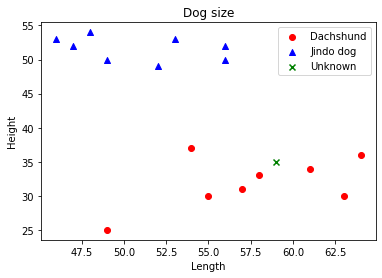

In [1]:
import matplotlib.pyplot as plt
dach_length = [55,57,64,63,58,49,54,61]
dach_height = [30,31,36,30,33,25,37,34]
jin_length  = [56,47,56,46,49,53,52,48]
jin_height  = [52,52,50,53,50,53,49,54]

newdata = [[59,35]]

plt.scatter(dach_length,dach_height,c='r',label='Dachshund')
plt.scatter(jin_length, jin_height, c='b',marker='^',label='Jindo dog')
plt.scatter(newdata[0][0], newdata[0][1], c='g',marker='x',label='Unknown')

plt.xlabel('Length')
plt.ylabel('Height')
plt.title('Dog size')
plt.legend(loc='upper right')

In [2]:
import numpy as np

d_data = np.column_stack((dach_length,dach_height))
d_label = np.zeros(len(d_data))

j_data = np.column_stack((jin_length, jin_height))
j_label = np.ones(len(j_data))

dogs   = np.concatenate([d_data, j_data])
labels = np.concatenate([d_label,j_label])

#print(d_data)
#print(dogs)

In [3]:
from sklearn.neighbors import KNeighborsClassifier

dog_classes = {0:'Dachshund',1:'Jindo Dog'}
k = 3
knn = KNeighborsClassifier(n_neighbors = k)
knn.fit(dogs,labels)
y_pred = knn.predict(newdata)

print('data',newdata,', prediction result: ',dog_classes[y_pred[0]])

data [[59, 35]] , prediction result:  Dachshund


In [4]:
from sklearn.datasets import load_iris

iris = load_iris()

print('iris data shape: ', iris.data.shape)
print('iris data features: ', iris.feature_names)
print('Iris data examples: ', iris.data[:3])
print('iris labels: ', iris.target)

iris data shape:  (150, 4)
iris data features:  ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Iris data examples:  [[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]]
iris labels:  [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


In [5]:
import pandas as pd

iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)
iris_df['target'] = pd.Series(iris.target)
iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [6]:
print('value counts of iris dataset')
iris_df['target'].value_counts()

value counts of iris dataset


target
0    50
1    50
2    50
Name: count, dtype: int64

In [7]:
print('values of iris dataset')
iris_df.values[:3]

values of iris dataset


array([[5.1, 3.5, 1.4, 0.2, 0. ],
       [4.9, 3. , 1.4, 0.2, 0. ],
       [4.7, 3.2, 1.3, 0.2, 0. ]])

In [8]:
X = iris_df.iloc[:,:4]
y = iris_df.iloc[:,-1]

print(X[:3])

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics

def iris_knn(X,y,k,newdata):
    X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.3)
    knn = KNeighborsClassifier(n_neighbors = k)
    knn.fit(X_train, y_train)
    y_pred_train = knn.predict(X_train)
    y_pred_test  = knn.predict(X_test)
    
    y_pred_unknown = knn.predict(newdata)
    
    scores_train = metrics.accuracy_score(y_train,y_pred_train)
    scores_test  = metrics.accuracy_score(y_test,y_pred_test)
    
    return scores_train, scores_test, y_test, y_pred_test, y_pred_unknown

X_unknown = [[4,2,1.3,0.4],
       [4,3,3.2,2.2]]

k = 3
scores_train, scores_test, y_test, pred_test, pred_unknown = iris_knn(X,y,k,X_unknown)

print('In case of n_neighbors = {0:d}, train accuracy:  {1:.3f}'.format(k,scores_train))
print('In case of n_neighbors = {0:d}, test accuracy: : {1:.3f}'.format(k,scores_test))

In case of n_neighbors = 3, train accuracy:  0.962
In case of n_neighbors = 3, test accuracy: : 0.978


C:\Users\yongo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


In [10]:
classes = {0:'setosa', 1:'versicolor', 2:'virginica'}
for i in range(len(X_unknown)):
    print('{} -> the predicted species: {}'.format(X_unknown[i], classes[pred_unknown[i]]))

[4, 2, 1.3, 0.4] -> the predicted species: setosa
[4, 3, 3.2, 2.2] -> the predicted species: versicolor


In [11]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test,pred_test)
print(cm)

[[13  0  0]
 [ 0 13  1]
 [ 0  0 18]]


<Axes: >

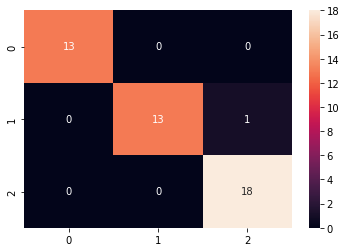

In [12]:
import seaborn as sns
sns.heatmap(cm,annot = True)